In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

1. Analyse du programme
    - dataset : `univariate_linear_regression_dataset.csv`
    - Input: la variable X
    - output: la variable Y
    - Technique utilisée : Régression Linéaire Simple (Univariée)

2. Identifier les étapes nécessaires à une application de Machine Learning
    1. Préparation des données (Data Preprocessing)
    2. Séparation des données (Train/Test Split)
    3. Entraînement du modèle
    4. Test

3. Quelle est le rôle de iloc ?
    - iloc est une propriété de la bibliothèque Pandas utilisée pour la sélection de données basée sur la position des entiers
    - La syntaxe générale est : `dataframe.iloc[indices_lignes, indices_colonnes]`
    - `:` signifie tout les elements

In [39]:
df = pd.read_csv('univariate_linear_regression_dataset.csv', header=None)
df.head()

,0,1
0,6.1101,17.5920
1,5.5277,9.1302
2,8.5186,13.6620
3,7.0032,11.8540
4,5.8598,6.8233


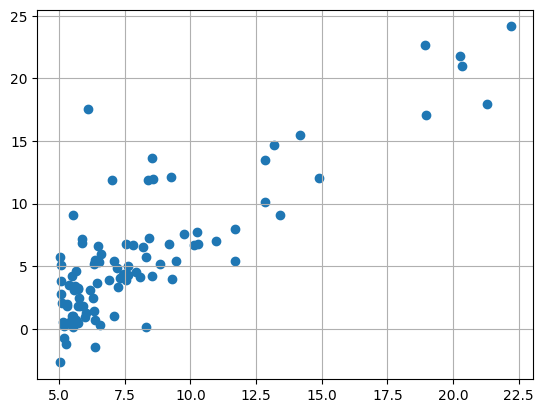

In [40]:
X = df.iloc[:,0]
Y = df.iloc[:,1]
axes = plt.axes()
axes.grid()
plt.scatter(X,Y)
plt.show()

In [41]:
SL=stats.linregress(X, Y)
slope=SL.slope
intercept=SL.intercept 
coef_correlation=SL.rvalue

print(f'''
      slope: {slope:.3f} 
      intercept: {intercept:.3f} 
      correlation coefficient: {coef_correlation:.3f}''')


      slope: 1.193 
      intercept: -3.896 
      correlation coefficient: 0.838


In [42]:
def predict(x):
    return slope * x + intercept

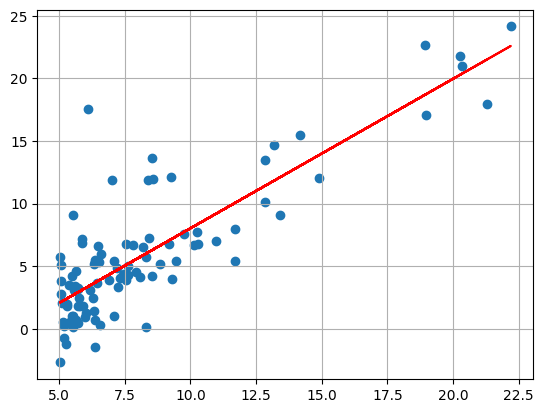

In [43]:
axes = plt.axes()
axes.grid()
plt.scatter(X,Y)
fitLine = predict(X)
plt.plot(X, fitLine, c='r')
plt.show()

In [44]:
val = predict(22.5).item()
print(f'f ( {22.5} ) = {val:.2f}')

f ( 22.5 ) = 22.95


---

1. Analyse du programme
    - Dataset (Jeu de données) : Toujours le fichier `univariate_linear_regression_dataset.csv`.
    - Input ($X$) :Initialement la colonne 0.
    - Technique utilisée : Régression Linéaire par Descente de Gradient (Gradient Descent).

2. Quel est le rôle n_iterations et learning_rate ? modifier la valeur et identifier l’impact sur le modèle ?<br>
    A. n_iterations (Nombre d'itérations)
    - C'est le nombre de fois que la boucle d'apprentissage met à jour le modèle.
    - Rôle : Détermine la durée de l'entraînement.
    - Impact de la modification :
        - Si trop faible (ex: 10) : Le modèle sera en Sous-apprentissage (Underfitting). La ligne rouge n'aura pas eu le temps de se placer correctement. La courbe d'erreur n'aura pas fini de descendre.
        - Si trop élevé (ex: 1 000 000) : Le modèle sera correct, mais vous aurez gaspillé du temps de calcul car l'erreur ne diminuait plus depuis longtemps (convergence déjà atteinte).
    B. learning_rate (Taux d'apprentissage)
    - C'est le coefficient qui contrôle la taille des pas effectués lors de la mise à jour des paramètres du modèle à chaque itération.
    - Rôle : Détermine la vitesse et la précision avec laquelle le modèle converge vers la solution optimale.
    - Impact de la modification :

        - Si trop faible (ex: 0.0001) : Le modèle apprend extrêmement lentement. La descente de gradient avance à tout petits pas, la courbe d'erreur descend très lentement et il faudra un très grand nombre d'itérations pour converger — voire ne jamais atteindre l'optimum dans le temps imparti.
        - Si trop élevé (ex: 10.0) : Le modèle diverge. Les pas sont si grands que l'algorithme "saute" par-dessus l'optimum et la courbe d'erreur remonte ou oscille de façon chaotique au lieu de descendre. Le modèle ne converge jamais.

In [45]:
x= df.iloc[:,0]
n_samples = len(x)
x=np.array(x).reshape((n_samples, 1))

y= df.iloc[:,1]
y=np.array(y).reshape((n_samples, 1))

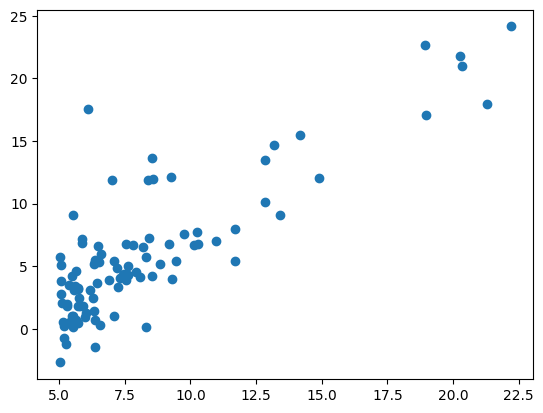

In [46]:
plt.scatter(x, y)
plt.show()

In [47]:
X = np.hstack((x, np.ones(x.shape)))
theta = np.random.randn(2, 1)
print(theta)

[[-0.17846437]
 [-0.30752336]]


In [48]:
def f(X, theta):
    return X.dot(theta)

def erreur_somme_des_distances(X, y, theta):
    m = len(y)
    return (1/(2*m))*np.sum((f(X, theta)-y)**2)

def gradient(X, y, theta):
    m = len(y)
    return 1/m * X.T.dot(f(X, theta) - y)

def gradient_descent(X, y, theta, learning_rate, n_iterations):
    historique_des_erreurs = np.zeros(n_iterations)
    for i in range(0, n_iterations):
        theta = theta - learning_rate * gradient(X, y, theta) # mise a jour du theta
        historique_des_erreurs[i] = erreur_somme_des_distances(X, y, theta)
    return theta, historique_des_erreurs

In [51]:
n_iterations = 10000
learning_rate = 1e-4 # modifier pour voir l'effet
theta_final, historique_des_erreurs=gradient_descent(X, y, theta, learning_rate, n_iterations)
print(theta_final) # theta une fois que la machine a été entrainée
# création d'un vecteur prédictions qui contient les prédictions de notre modele final
predictions = f(X, theta_final)

[[ 0.88357919]
 [-0.81543207]]


In [ ]:
learning_rates = [1, 1e-1, 1e-2, 1e-3]

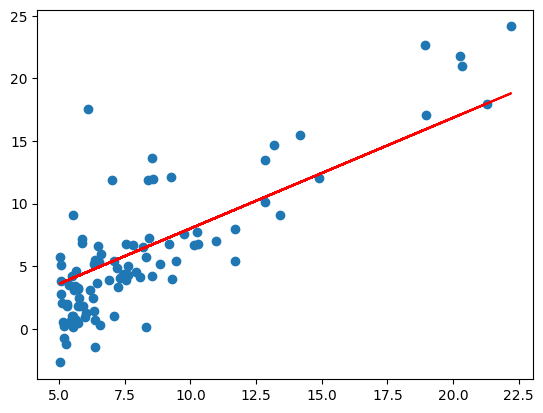

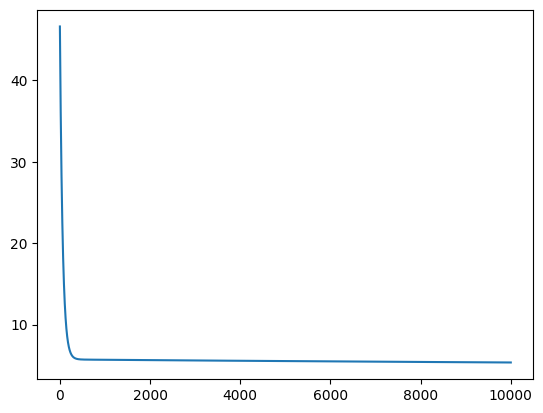

[19.06509981]


In [52]:
plt.scatter(x, y)
plt.plot(x, predictions, c='r')
plt.show()
plt.figure()
plt.plot(range(n_iterations), historique_des_erreurs)
plt.show()
print(f(np.array([22.5,1]), theta_final))

---

1. Analyse du programme
- Dataset : `dataset_polynomial3.csv`.
- Input (variable prédictive) : colonne 0 → x
- Output (variable cible) : colonne 1 → y
- Technique utilisée : Régression polynomiale de degré 2 via np.polyfit, qui cherche les coefficients a, b, c tels que y ≈ ax² + bx + c en minimisant l'erreur quadratique.

2. Rôle des deux fonctions
- `afficher_pol(LPol)` prend la liste des coefficients du polynôme et l'affiche sous forme lisible, terme par terme. 
- `evaluer_pol(LPol, x)` calcule numériquement la valeur du polynôme en un point x donné, en faisant la somme `Σ coeff_i * x^i`. Elle sert à obtenir une prédiction ŷ pour une valeur x précise, ce que `np.poly1d` fait aussi mais de façon moins explicite.

In [53]:
def afficher_pol(LPol):
    L=LPol[:]; L.reverse()
    L=[round(e,2) for e in L]
    for i in range(len(L)):
        print('('+str(L[i])+'*X^'+str(i)+')',end='+')

def Evaluer_pol(LPol,x):
    s=0
    L=LPol[:]
    L.reverse()
    for i in range(len(LPol)):
        s+=L[i]*(x**i)
    return(s)

(-3.45*X^0)+(1.84*X^1)+(-0.04*X^2)+

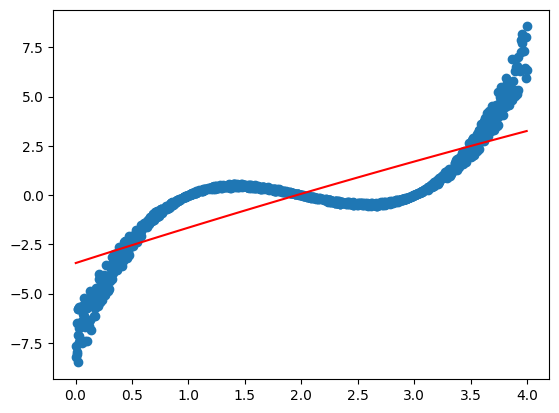

In [55]:
data=pd.read_csv('dataset_polynomial3.csv').values
x=data[1:1001,0]
y=data[1:1001,1]
degre_polynome=2
p= np.poly1d(np.polyfit(x, y,degre_polynome))
LPol=list(p)
afficher_pol(LPol)
les_x = np.linspace(min(x), max(x), 100)
plt.scatter(x, y)
plt.plot(les_x, p(les_x), c='r')
plt.show()

4. Est-ce que le polynôme modélise correctement la relation entre la variable prédictive et la variable cible ? Non, le polynome adequat sera de degre 3

(-7.38*X^0)+(13.53*X^1)+(-7.38*X^2)+(1.23*X^3)+

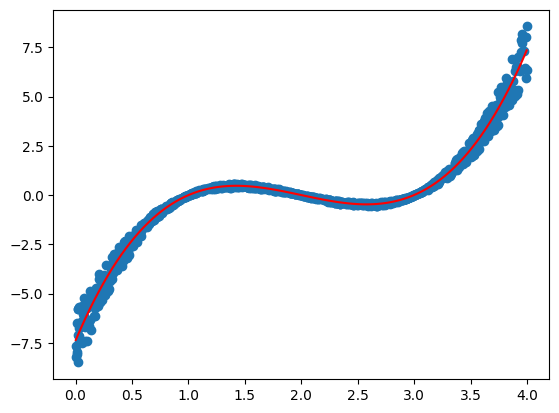

In [67]:
degre_polynome=3
p= np.poly1d(np.polyfit(x, y,degre_polynome))
LPol=list(p)
afficher_pol(LPol)
les_x = np.linspace(min(x), max(x), 100)
plt.scatter(x, y)
plt.plot(les_x, p(les_x), c='r')
plt.show()